In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.special as sps
from scipy import *
import warnings
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy import stats
import statsmodels.api as sm
from datetime import datetime
import pandas as pd
import yfinance as yf

In [ ]:
startdate = datetime(2018, 1, 1)
enddate = datetime(2019, 8, 31)
df = yf.download(tickers='GOOG', start=startdate, end=enddate, auto_adjust=False)
df.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 419 entries, 2018-01-02 to 2019-08-30
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GOOG)  419 non-null    float64
 1   (Close, GOOG)      419 non-null    float64
 2   (High, GOOG)       419 non-null    float64
 3   (Low, GOOG)        419 non-null    float64
 4   (Open, GOOG)       419 non-null    float64
 5   (Volume, GOOG)     419 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 22.9 KB


In [ ]:
# Переведем загловки столбцов в нижний регистр и посмотрим на данные
df.columns = ['Adj Close', 'Close', 'Hight', 'Low', 'Open', 'Volume']
df.columns = map(str.lower, df.columns)
df.head()

,adj close,close,hight,low,open,volume
Date,,,,,,
2018-01-02,52.998970,53.250000,53.347000,52.261501,52.417000,24752000
2018-01-03,53.868851,54.124001,54.314499,53.160500,53.215500,28604000
2018-01-04,54.063927,54.320000,54.678501,54.200100,54.400002,20092000
2018-01-05,54.851696,55.111500,55.212502,54.599998,54.700001,25582000
2018-01-08,55.086086,55.347000,55.563499,55.081001,55.111500,20952000


Text(0.5, 1.0, 'График разниы между ценой закрытия и открытия')

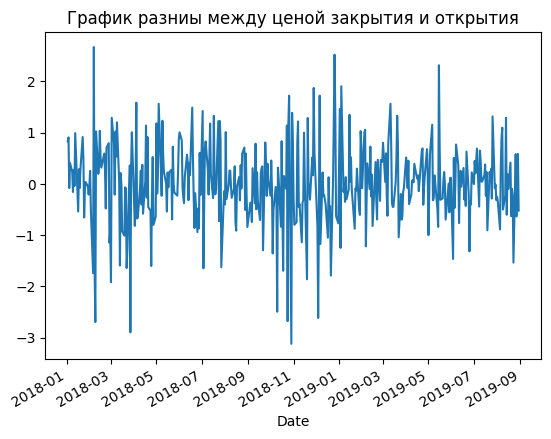

In [ ]:
# Готовим новую метрику.
df["diff_price"] = df.close - df.open
df.diff_price.plot()
plt.title("График разниы между ценой закрытия и открытия")

In [ ]:
def my_basic_research(df=df, column = "diff_price"):
    print("Базовые метрики")
    print(df[column].describe())
    print("------------------------------------")

    print("Самые популярные значения метрики, топ 5")
    print(df[column].value_counts().nlargest(5))
    print("------------------------------------")

    print("Эксцесс ", kurtosis(df[column]))
    print("Ассиметрия ", skew(df[column]))

    sns.distplot(df[column])
    plt.title("Распределение метрики")

Базовые метрики
count    419.000000
mean       0.014167
std        0.789271
min       -3.119499
25%       -0.375252
50%       -0.002502
75%        0.460249
max        2.670998
Name: diff_price, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
diff_price
-0.102501    2
 1.565498    2
-0.538502    2
 0.225002    2
 0.465500    2
Name: count, dtype: int64
------------------------------------
Эксцесс  1.8273103799452652
Ассиметрия  -0.37369326670455244


<ipython-input-14-23d701b4a01c>:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column])


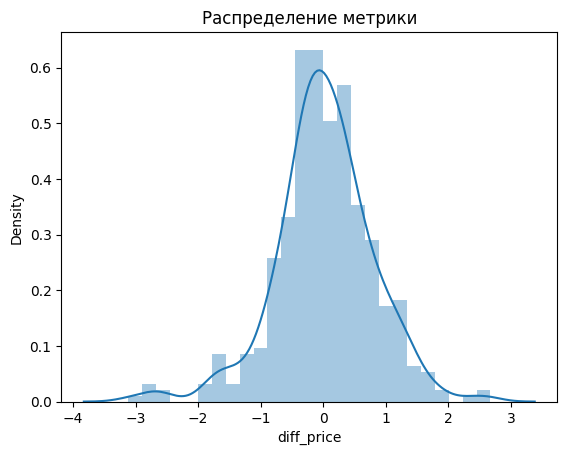

In [ ]:
my_basic_research(column = "diff_price")

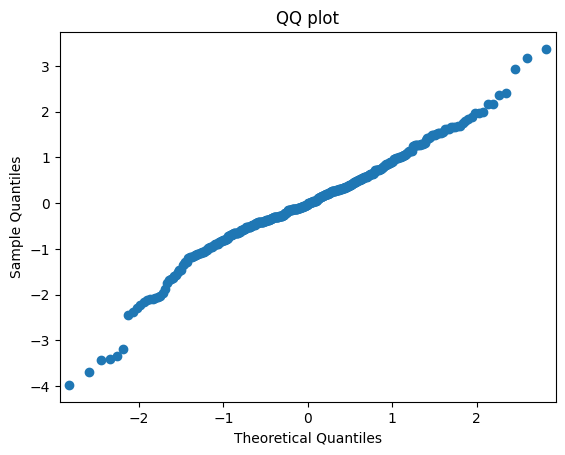

In [ ]:
sm.qqplot(df.diff_price, fit = True)
plt.title("QQ plot")
plt.show()

In [ ]:
def my_norm_confidence(df=df, column = "diff_price", alpha = 0.95):
    interval = stats.norm.interval(alpha, loc=df[column].mean(), scale=df[column].std())
    return interval

In [28]:
confidence = my_norm_confidence()
print(confidence)

(np.float64(-1.5327760166084672), np.float64(1.561109147947966))


Text(0.5, 1.0, 'Доверительный интервал')

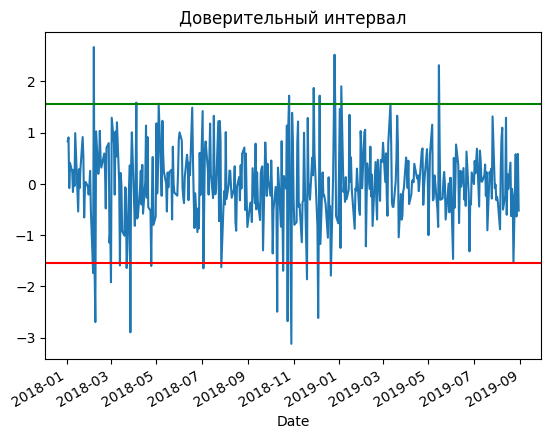

In [ ]:
df.diff_price.plot()
plt.axhline(y=confidence[1], color="g", linestyle="-")
plt.axhline(y=confidence[0], color="r", linestyle="-")
plt.title("Доверительный интервал")

In [ ]:
df["anomaly_big"] = np.where(df.diff_price > confidence[1], 1,0)
df[df.anomaly_big == 1].describe()

,adj close,close,hight,low,open,volume,diff_price,anomaly_big
count,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000e+01,10.000000,10.0
mean,53.897318,54.152600,54.409340,52.025955,52.207301,5.155860e+07,1.945299,1.0
std,2.469182,2.480877,2.530910,2.547175,2.496866,1.477136e+07,0.411089,0.0
min,51.015369,51.257000,51.435902,49.150002,49.450500,3.438400e+07,1.565498,1.0
25%,52.418720,52.667000,52.704624,50.922963,50.973501,4.285500e+07,1.620374,1.0
50%,53.302040,53.554501,53.822750,51.454700,51.671251,4.848700e+07,1.798500,1.0
75%,53.985428,54.241125,55.080375,51.767123,52.291375,5.396150e+07,2.214248,1.0
max,58.510864,58.787998,58.809502,57.222500,57.222500,8.375200e+07,2.670998,1.0


In [26]:
confidence_90 = my_norm_confidence(alpha = 0.9)
print(confidence_90)

(np.float64(-1.2840685739637576), np.float64(1.3124017053032557))


In [27]:
df["anomaly_big_90"] = np.where(df.diff_price > confidence_90[1], 1,0)
df[df.anomaly_big_90 == 1].describe()

,adj close,close,hight,low,open,volume,diff_price,anomaly_big,anomaly_big_90
count,19.000000,19.000000,19.000000,19.000000,19.000000,1.900000e+01,19.000000,19.0,19.0
mean,55.022834,55.283447,55.509626,53.405660,53.605448,4.776063e+07,1.678000,1.0,1.0
std,3.499173,3.515747,3.588238,3.750988,3.642578,1.909615e+07,0.412453,0.0,0.0
min,51.015369,51.257000,51.435902,49.150002,49.450500,2.434600e+07,1.318501,1.0,1.0
25%,52.104706,52.351500,52.520750,50.815250,50.851250,3.329600e+07,1.368250,1.0,1.0
50%,53.603607,53.857498,54.085499,51.704498,51.851501,4.454800e+07,1.565498,1.0,1.0
75%,58.166246,58.441750,58.641001,56.506401,56.538000,5.253900e+07,1.798500,1.0,1.0
max,62.225773,62.520500,63.277500,61.200001,61.202000,9.611600e+07,2.670998,1.0,1.0


Text(0.5, 1.0, 'Доверительный интервал')

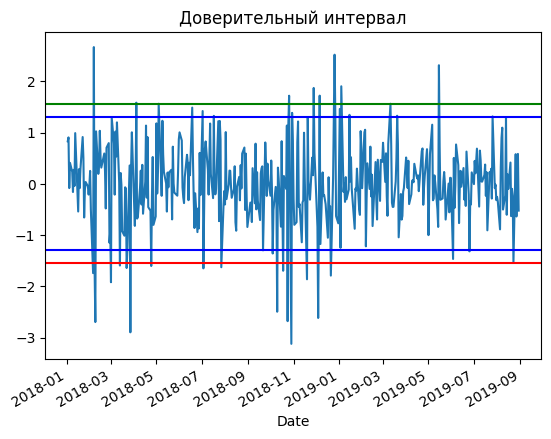

In [30]:
df.diff_price.plot()
plt.axhline(y=confidence[1], color="g", linestyle="-")
plt.axhline(y=confidence[0], color="r", linestyle="-")
plt.axhline(y=confidence_90[1], color="b", linestyle="-")
plt.axhline(y=confidence_90[0], color="b", linestyle="-")
plt.title("Доверительный интервал")